## Ввведение

### Примеры методов МО в жизни :
1. спам-фильтры (автомат.определяют и перемещают рекламу в папку "спам")
2. рек.системы (рилсы, тиктоки итд видео которые нам релевантны)
3. детекция лица (face id, , быстро и удобно)
4. распознавание рентген снимков
5. голосовые помошники (алиса, сири итд)

### Классификация задач 

1. Определение спама в письмах -> Бинарная классификация
2. Распознавание рукописных цифр -> Многоклассовая классификация (2)
3. Прогнозирование цены акций -> Регрессия (временные ряды) (1, 3)
4. Сегментация клиентов по поведению -> Кластеризация (5)
5. Рекомендация фильмов -> Коллаборативная фильтрация
   
### Разница между многоклассовой классификацией и мультилейбл классификацией:
**Многоклассовая классификация (Multiclass Classification):**

- Каждый объект относится только к одному классу из множества взаимоисключающих классов
Пример: распознавание цифр (0-9) - изображение может быть только одной цифрой
Сумма вероятностей всех классов = 1

**Мультилейбл классификация (Multilabel Classification):**
- Каждый объект может принадлежать одновременно к нескольким классам
Пример: определение жанров фильма - фильм может быть одновременно "комедией", "боевиком" и "драмой"
Каждый класс рассматривается независимо (бинарная классификация для каждого)

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import lightgbm 
import scipy 
import statsmodels 
import matplotlib.pyplot as plt 
import seaborn as sns

In [47]:
data = pd.read_json('data/train.json')
data

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.000000,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.710800,7170325,-73.953900,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.000000,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.751300,7092344,-73.972200,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.000000,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.757500,7158677,-73.962500,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.500000,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.714500,7211212,-73.942500,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.000000,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.743900,7225292,-73.974300,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.000000,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.843300,6824800,-73.939600,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.000000,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.819800,6813268,-73.957800,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.000000,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.576500,6927093,-73.955400,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.000000,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.744800,6892816,-74.001700,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [48]:
data.shape

(49352, 15)

In [49]:
data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

#### Aim columns is *PRICE*

In [50]:
df = pd.DataFrame(data)
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.000000,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.710800,7170325,-73.953900,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.000000,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.751300,7092344,-73.972200,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.000000,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.757500,7158677,-73.962500,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.500000,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.714500,7211212,-73.942500,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.000000,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.743900,7225292,-73.974300,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [52]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000
mean,1.212180,1.541640,40.741545,7024054.655394,-73.955716,3830.174036
std,0.501420,1.115018,0.638535,126274.611244,1.177912,22066.865885
min,0.000000,0.000000,0.000000,6811957.000000,-118.271000,43.000000
25%,1.000000,1.000000,40.728300,6915887.500000,-73.991700,2500.000000
50%,1.000000,1.000000,40.751800,7021070.500000,-73.977900,3150.000000
75%,1.000000,2.000000,40.774300,7128733.250000,-73.954800,4100.000000
max,10.000000,8.000000,44.883500,7753784.000000,0.000000,4490000.000000


In [53]:
correlation_matrix = data.select_dtypes(include=['number']).corr()
correlation_matrix

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


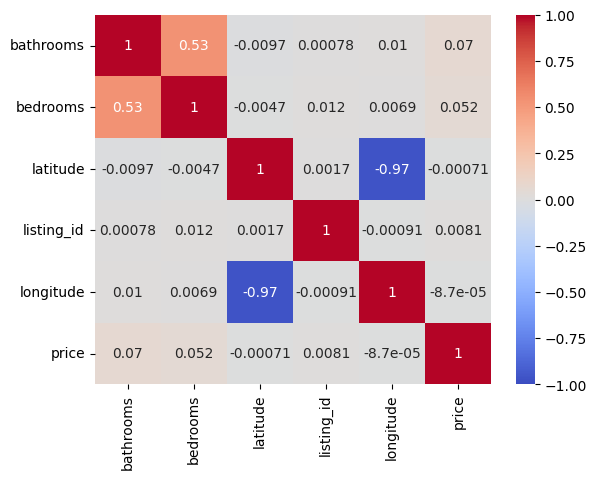

In [54]:

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'. Create a dataframe with only these columns.

In [55]:
df = data[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.000000,1,medium,2400
6,1.000000,2,low,3800
9,1.000000,2,medium,3495
10,1.500000,3,medium,3000
15,1.000000,0,low,2795


<Axes: >

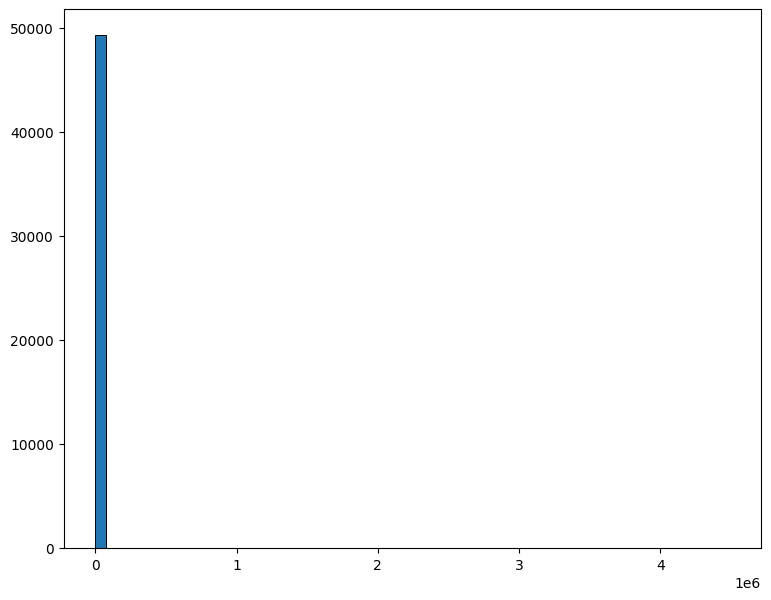

In [56]:
df['price'].hist(bins=60, figsize=(9, 7), grid = False, edgecolor='black', linewidth=0.7)

{'whiskers': [<matplotlib.lines.Line2D at 0x79c1c5c33800>,
 'caps': [<matplotlib.lines.Line2D at 0x79c1c5c32c60>,
 'boxes': [<matplotlib.lines.Line2D at 0x79c1c5c33d40>],
 'medians': [<matplotlib.lines.Line2D at 0x79c1c5c32180>],
 'fliers': [<matplotlib.lines.Line2D at 0x79c1c5c31c40>],
 'means': []}

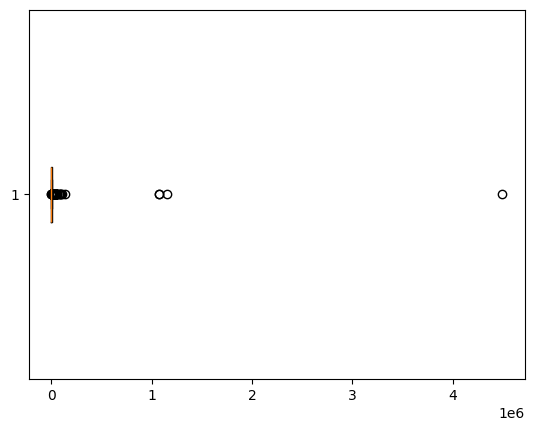

In [57]:
plt.boxplot(df['price'].values, vert=False)

In [58]:
q_1 = data['price'].quantile(0.01)
q_99 = data['price'].quantile(0.99)

df_clean = df[(df['price'] >= q_1) & (df['price'] <= q_99)]

<Axes: >

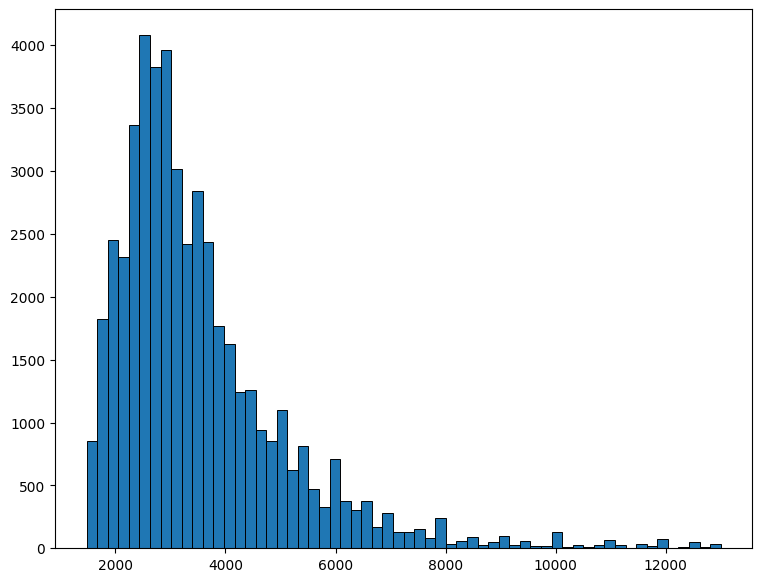

In [59]:
df_clean['price'].hist(bins=60, figsize=(9, 7), grid = False, edgecolor='black', linewidth=0.7)

In [60]:
print(df_clean['interest_level'].dtype)
print(df_clean['interest_level'].values)
print(df_clean['interest_level'].value_counts())
print(df_clean['interest_level'].unique())

object
['medium' 'low' 'medium' ... 'medium' 'medium' 'high']
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64
['medium' 'low' 'high']


In [61]:
mapping = {'low': 0, 'medium': 1, 'high': 2}
df_clean['interest_level'] = df_clean['interest_level'].map(mapping)

/tmp/ipykernel_654/51800792.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['interest_level'] = df_clean['interest_level'].map(mapping)


In [62]:
df_clean

,bathrooms,bedrooms,interest_level,price
4,1.000000,1,1,2400
6,1.000000,2,0,3800
9,1.000000,2,1,3495
10,1.500000,3,1,3000
15,1.000000,0,0,2795
...,...,...,...,...
124000,1.000000,3,0,2800
124002,1.000000,2,1,2395
124004,1.000000,1,1,1850
124008,1.000000,2,1,4195


<Axes: >

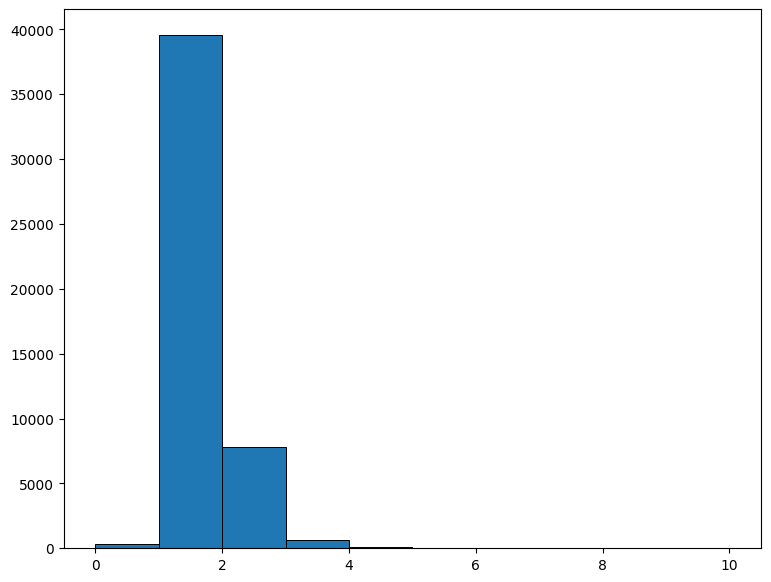

In [63]:
df_clean['bathrooms'].hist(bins=10, figsize=(9, 7), grid = False, edgecolor='black', linewidth=0.7)

<Axes: >

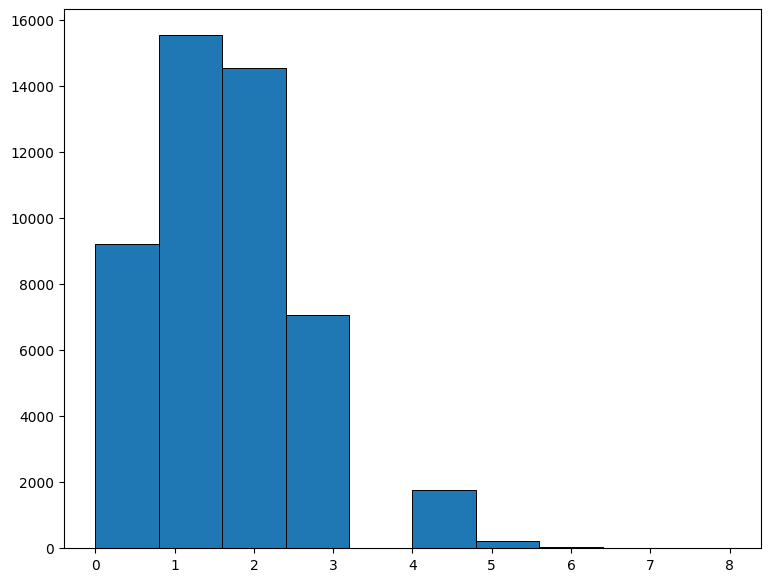

In [64]:
df_clean['bedrooms'].hist(bins=10, figsize=(9, 7), grid = False, edgecolor='black', linewidth=0.7)

In [65]:
df_clean.dtypes

bathrooms         float64
bedrooms            int64
interest_level      int64
price               int64
dtype: object

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


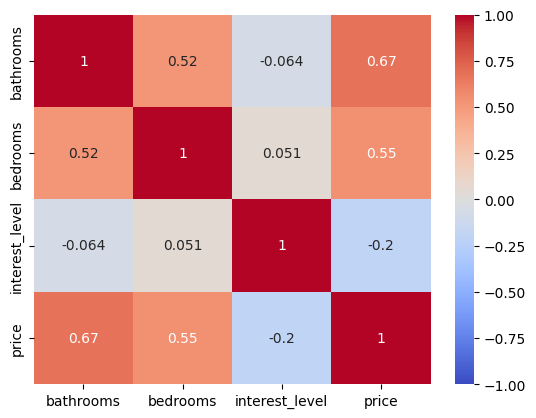

In [66]:
corr_matrix = df_clean.corr()
display(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin= -1, vmax = 1)
plt.show()

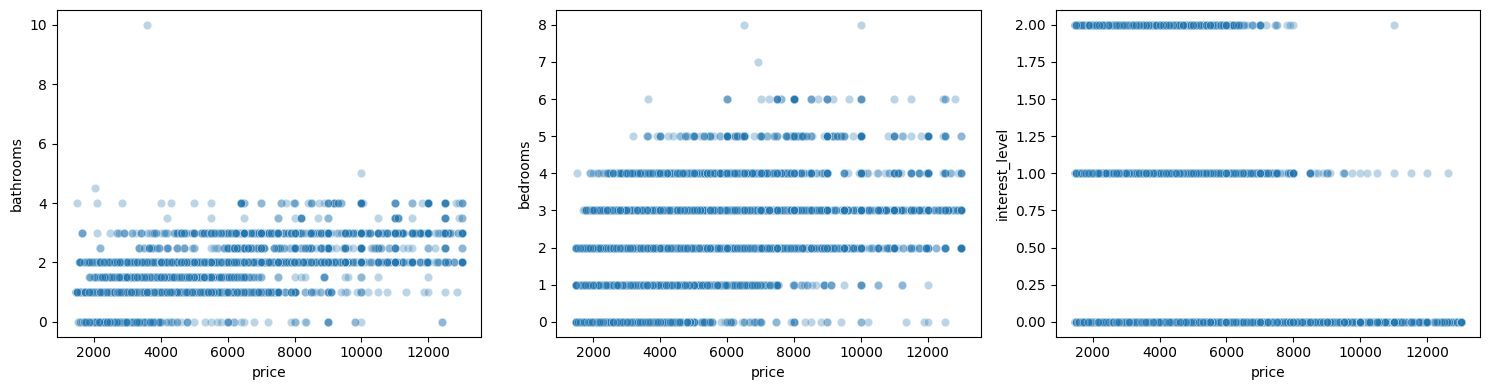

In [67]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x='price', y='bathrooms', alpha=0.3)

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x='price', y='bedrooms', alpha=0.3)

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x='price', y='interest_level', alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
df_clean['bathrooms_squared'] = df_clean['bathrooms'].map(lambda x: x**2)
df_clean['bedrooms_squared'] = df_clean['bedrooms'].map(lambda x: x**2)
df_clean['interest_level_squared'] = df_clean['interest_level'].map(lambda x: x**2)

/tmp/ipykernel_654/623952903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bathrooms_squared'] = df_clean['bathrooms'].map(lambda x: x**2)
/tmp/ipykernel_654/623952903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bedrooms_squared'] = df_clean['bedrooms'].map(lambda x: x**2)
/tmp/ipykernel_654/623952903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

<Axes: >

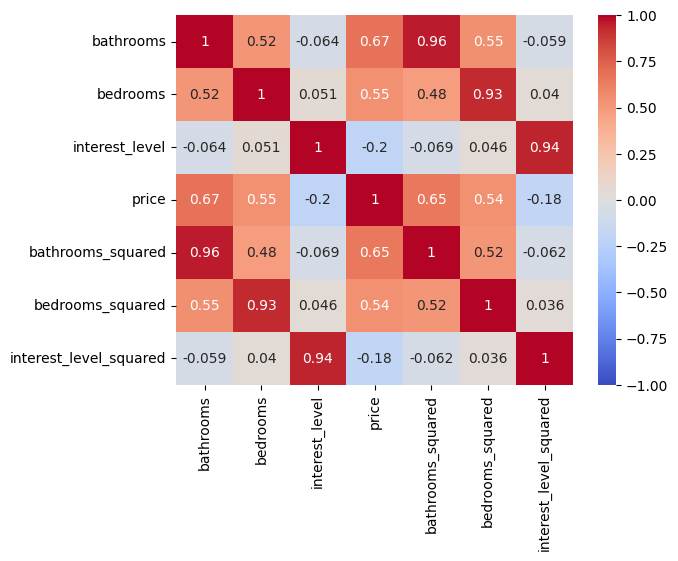

In [69]:
matrx = df_clean.corr()
sns.heatmap(matrx, annot=True, cmap='coolwarm', vmin= -1, vmax = 1)

In [70]:
df_for_learn = df_clean[['bathrooms', 'bedrooms', 'price']]

In [71]:
df_for_learn

,bathrooms,bedrooms,price
4,1.000000,1,2400
6,1.000000,2,3800
9,1.000000,2,3495
10,1.500000,3,3000
15,1.000000,0,2795
...,...,...,...
124000,1.000000,3,2800
124002,1.000000,2,2395
124004,1.000000,1,1850
124008,1.000000,2,4195


In [72]:
X_train = df_for_learn.drop('price', axis=1)
y_train = df_for_learn['price']

In [73]:
df_test = pd.read_json('data/test.json')

In [74]:
df_test.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
dtype: int64

In [75]:
df_test = df_test[['bathrooms', 'bedrooms', 'price']]
df_test

,bathrooms,bedrooms,price
0,1.000000,1,2950
1,1.000000,2,2850
2,1.000000,0,2295
3,1.000000,2,2900
5,1.000000,1,3254
...,...,...,...
124003,1.000000,1,1700
124005,1.000000,2,4195
124006,1.000000,0,2400
124007,2.000000,2,6895


In [76]:
X_test = df_test.drop('price', axis=1)
y_test = df_test['price']

In [77]:
poly = PolynomialFeatures(degree=10, include_bias=False, interaction_only=True)

In [78]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [79]:
result_MAE = pd.DataFrame(columns = ['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns = ['model', 'train', 'test'])

In [80]:
y_test.shape

(74659,)

## LinearRegression

In [81]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)

prediction_val = model.predict(X_test_poly)
prediction_train = model.predict(X_train_poly)

mae_val = np.mean(np.abs(y_test - prediction_val))
rmse_val = np.sqrt(np.mean((y_test - prediction_val)**2))

mae_train = np.mean(np.abs(y_train - prediction_train))
rmse_train = np.sqrt(np.mean((y_train - prediction_train)**2)) 

In [82]:
result_MAE.loc[0] = ['linear_regression', mae_train, mae_val]
result_RMSE.loc[0] = ['linear_regression', rmse_train, rmse_val]

## DesicionTree

In [83]:
from sklearn.tree import DecisionTreeRegressor

model_tree= DecisionTreeRegressor(random_state=21)
model_tree.fit(X_train_poly, y_train)

prediction_tree_train = model_tree.predict(X_train_poly)
prediction_tree_val = model_tree.predict(X_test_poly)


mae_val_tree = np.mean(np.abs(y_test - prediction_tree_val))
rmse_val_tree  = np.sqrt(np.mean((y_test - prediction_tree_val)**2))

mae_train_tree = np.mean(np.abs(y_train - prediction_tree_train))
rmse_train_tree = np.sqrt(np.mean((y_train - prediction_tree_train)**2))


In [84]:
result_MAE.loc[1] = ['decision_tree', mae_train_tree, mae_val_tree]
result_RMSE.loc[1] = ['decision_tree', rmse_train_tree, rmse_val_tree]


### Наивная модель (baseline model) — это простейшая модель, которая используется как отправная точка для сравнения. Она не учится на признаках, а делает предсказания по простому правилу.

*Простые примеры наивных моделей для регрессии:*
* Предсказание среднего: всегда предсказываем среднюю цену из обучающей выборки
* Предсказание медианы: всегда предсказываем медианную цену из обучающей выборки
* Предсказание предыдущего значения: для временных рядов
* Наивная модель показывает минимальный уровень качества, который должна превзойти любая "умная" модель. Если сложная модель работает хуже наивной — значит, что-то не так

In [85]:
mean_price = y_train.mean()
median_price = y_train.median()

#Создаем "предсказания" для наивных моделей
# Для каждой строки просто повторяем одно и то же значение
naive_mean_train_pred = np.full(len(y_train), mean_price) 

# Синтаксис: np.full(shape, fill_value), np.full() создает массив (array) заполненный указанным значением.
# shape - сколько элементов, fill_value - чем заполнить
naive_mean_test_pred = np.full(len(y_test), mean_price)

naive_median_train_pred = np.full(len(y_train), median_price)
naive_median_test_pred = np.full(len(y_test), median_price)

In [86]:
mae_mean_train = np.mean(np.abs(naive_mean_train_pred - y_train))
mae_mean_test = np.mean(np.abs(naive_mean_test_pred - y_test))

rmse_mean_train = np.sqrt(np.mean((naive_mean_train_pred - y_train)**2))
rmse_mean_test = np.sqrt(np.mean((naive_mean_test_pred - y_test)**2))

mae_median_train = np.mean(np.abs(naive_median_train_pred - y_train))
mae_median_test = np.mean(np.abs(naive_median_test_pred - y_test))

rmse_median_train = np.sqrt(np.mean((naive_median_train_pred - y_train)**2))
rmse_median_test = np.sqrt(np.mean((naive_median_test_pred - y_test)**2))

In [87]:
result_MAE.loc[2] = ['naive_mean', mae_mean_train, mae_mean_test]
result_MAE.loc[3] = ['naive_median', mae_median_train, mae_median_test]

result_RMSE.loc[2] = ['naive_mean', rmse_mean_train, rmse_mean_test]
result_RMSE.loc[3] = ['naive_median', rmse_median_train, rmse_median_test]

In [88]:
pd.set_option('display.float_format', '{:.6f}'.format) 

In [89]:
result_MAE

,model,train,test
0,linear_regression,784.657881,985.387111
1,decision_tree,756.044735,953.296199
2,naive_mean,1139.192515,1374.695973
3,naive_median,1086.210505,1322.640673


### Decision Tree - по данной метрике показала лучший результат 

In [90]:
result_RMSE

,model,train,test
0,linear_regression,1123.636046,9624.404490
1,decision_tree,1077.483596,9588.793066
2,naive_mean,1597.646655,9715.305011
3,naive_median,1644.236439,9731.481148
